# Sistema de Recomendación de Anime

# Parte 1: EDA y preprocesamiento

---

## Contenido 

1. Carga de datos
2. Exploración (EDA)
3. Preprocesamiento
4. Modelo Base (Baseline)
5. Guardado de splits


## 0. Imports


In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")


## 1. Carga de datos

In [119]:
df_anime_original = pd.read_csv("anime.csv")
df_rating_original = pd.read_csv("rating.csv")

print(f"anime csv -> {df_anime_original.shape[0]} filas, {df_anime_original.shape[1]} columnas")
print(f"rating csv -> {df_rating_original.shape[0]} filas, {df_rating_original.shape[1]} columnas")

anime csv -> 12294 filas, 7 columnas
rating csv -> 7813737 filas, 3 columnas


In [120]:
df_rating_original["rating"].value_counts()

rating
 8     1646019
-1     1476496
 7     1375287
 9     1254096
 10     955715
 6      637775
 5      282806
 4      104291
 3       41453
 2       23150
 1       16649
Name: count, dtype: int64

In [121]:
df_anime_original.sample(5)

,anime_id,name,genre,type,episodes,rating,members
10948,33071,Bungou Stray Dogs OVA,"Mystery, Seinen, Supernatural",OVA,1,NaN,8350
4821,2560,Terra e...,"Action, Drama, Sci-Fi, Shounen",Movie,1,6.63,4807
9907,30905,Owanko,Comedy,ONA,7,5.17,65
4262,10005,Tetsujin 28-gou: Hakuchuu no Zangetsu,"Action, Adventure, Mecha, Sci-Fi",Movie,1,6.77,404
3439,5967,Kinnikuman II Sei: Ultimate Muscle,"Action, Comedy, Martial Arts, Sci-Fi, Shounen,...",TV,13,6.99,2435


In [122]:
df_rating_original.sample(5)

,user_id,anime_id,rating
6773198,62657,934,-1
3540003,32775,7817,7
4472032,42287,12293,-1
4556903,43466,10330,7
247277,2562,24833,8


Según la estructura de los datasets, el dataset ``rating.csv`` funciona de la siguiente manera:

- Si un registro existe (hay una fila con user_id y anime_id): Significa que el usuario ha visto (o al menos añadido a su lista) ese anime.
- Si el rating es un número del 1 al 10: El usuario lo ha visto y le ha puesto esa nota explícita.
- Si el rating es -1: El usuario lo ha visto (o interactuado/añadido a su perfil), pero no le ha puesto una nota o valoración numérica.

# 2. EDA -- Análisis exploratorio

In [123]:
print("-"*5 + " Tipos y valores nulos en anime.csv " + "-"*5)
df_anime = df_anime_original.convert_dtypes()
print()
print(df_anime.dtypes)

print("\nValores:nulos: ")
print(df_anime.isnull().sum())

print(df_anime.describe())

----- Tipos y valores nulos en anime.csv -----

anime_id             Int64
name        string[python]
genre       string[python]
type        string[python]
episodes    string[python]
rating             Float64
members              Int64
dtype: object

Valores:nulos: 
anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64
           anime_id    rating       members
count       12294.0   12064.0       12294.0
mean   14058.221653  6.473902  18071.338864
std    11455.294701  1.026746  54820.676925
min             1.0      1.67           5.0
25%         3484.25      5.88         225.0
50%         10260.5      6.57        1550.0
75%         24794.5      7.18        9437.0
max         34527.0      10.0     1013917.0


In [124]:
print("-"*5 + " Tipos y valores nulos en rating.csv " + "-"*5)
df_rating_original = df_rating_original.convert_dtypes()
print(df_rating_original.dtypes)

print("\nValores:nulos: ")
print(df_rating_original.isnull().sum())

print(df_rating_original.describe())

----- Tipos y valores nulos en rating.csv -----
user_id     Int64
anime_id    Int64
rating      Int64
dtype: object

Valores:nulos: 
user_id     0
anime_id    0
rating      0
dtype: int64
            user_id     anime_id     rating
count     7813737.0    7813737.0  7813737.0
mean   36727.956745  8909.072104    6.14403
std    20997.946119  8883.949636     3.7278
min             1.0          1.0       -1.0
25%         18974.0       1240.0        6.0
50%         36791.0       6213.0        7.0
75%         54757.0      14093.0        9.0
max         73516.0      34519.0       10.0


## 3. Preprocesamiento

Generamos dos versiones del dataset:

| Versión | Uso | Ratings |
|---|---|---|
| `ratings_explicito` | CF (KNN) y SVD | Solo 1-10 (sin -1) |
| `ratings_binario` | Bernoulli MF | Binarizado: ≥7 → 1, resto → 0 |

In [125]:
df_rating = df_rating_original[df_rating_original['rating'] != -1].copy()

# Usuarios único e items unicos
NUM_USERS = df_rating["user_id"].nunique()
NUM_ITEMS = df_rating["anime_id"].nunique()
NUM_RATINGS = len(df_rating)
sparsity = 1 - NUM_RATINGS / (NUM_USERS * NUM_ITEMS)


print(f'Usuarios únicos : {NUM_USERS:,}')
print(f'Animes únicos   : {NUM_ITEMS:,}')
print(f'Total ratings   : {NUM_RATINGS:,}')
print(f'Sparsity        : {sparsity:.4%}')  # Cuánto vacío tiene la matriz


Usuarios únicos : 69,600
Animes únicos   : 9,927
Total ratings   : 6,337,241
Sparsity        : 99.0828%


In [126]:
# Agrupar por user_id
stats_por_usuario = df_rating.groupby('user_id')['rating'].agg(['count', 'mean'])

stats_por_usuario.columns = ['animes_valorados', 'nota_media_dada']

# Ordenar para ver los usuarios más activos
stats_por_usuario = stats_por_usuario.sort_values(by='animes_valorados', ascending=False)

stats_por_usuario.head(10)

,animes_valorados,nota_media_dada
user_id,,
42635,3747,6.354951
53698,2905,6.546644
57620,2689,7.964299
59643,2632,7.043693
51693,2621,6.594811
45659,2462,6.950447
7345,2429,6.164677
12431,2348,3.96891
65840,2215,7.288488


El cold start problem en recommendation systems ocurre cuando falta historial de interacciones para nuevos usuarios/items/sistema entero. Tipos:

- User cold start: Nuevo usuario sin ratings. P(u)=? sin vecinos en user-item matrix.

- Item cold start: Nuevo ítem sin ratings. No se recomienda por similitud.

- System cold start: Plataforma vacía (pocos usuarios/items).

En collaborative filtering, precisión baja porque $\hat{r}_{u,i}$ depende de datos históricos. Matemáticamente, para KNN: vecinos vacíos → fallback a populares

Complejidad: $O(1)$ detección, pero resolución $O(n)$ datos recolectados

Al emplear un proceso de filtrado naïve, obtenemos un proceso que se retroalimenta, es decir, si filtras usuarios primero, luego algunos animes pierden ratings y caen por debajo del mínimo; si vuelves a filtrar ítems, algunos pierden ratings y vuelven a caer.

Es por ello que vamos a aplicar un **filtrado iterativo hasta convergencia**.

Sea **$R$** la matriz de interacciones usuario-item. Definimos:

$$U_{valid} = \{u \mid \left|R_{u}\right| \ge k_{user}\}$$
$$I_{valid} = \{i \mid \left|R_{i}\right| \ge k_{item}\}$$

El proceso iterativo aplica: 

$$R^{(t+1)} = R^{(t)} \left[ U_{valid}^{(t)}, I_{valid}^{(t)} \right]$$

hatsa que $R^{(t+1)} = R^{(t)}$, es decir, hasta que ninguna fila ni columna queda por debajo del umbral. Se garantiza convergencia porque $\left|R^{(t+1)}\right| \le \left|R^{(t)}\right|$ en cada paso (el conjunto nunca crece).

⁡


In [127]:
# Filtrado de cold start vectorizada


def filter_cold_start_fast(df, min_user=20, min_item=20):
    """
    Filtrado iterativo vectorizado con máscara acumulada.
    
    La clave: 'active_mask' opera siempre sobre el DataFrame original
    completo. Nunca se reduce el array subyacente dentro del bucle,
    solo se actualiza qué filas están 'activas'.
    
    Complejidad: O(I * N) donde I = iteraciones, N = filas originales
    """
    # Máscara acumulada sobre el DataFrame ORIGINAL (tamaño fijo)
    active_mask = np.ones(len(df), dtype=bool)

    users_orig  = df['user_id'].values   # nunca se modifica
    items_orig  = df['anime_id'].values  # nunca se modifica

    prev_active = -1
    iteration   = 0

    while active_mask.sum() != prev_active:
        prev_active = active_mask.sum()
        iteration  += 1

        # Trabajamos solo con las filas activas
        active_users = users_orig[active_mask]
        active_items = items_orig[active_mask]

        # Contar frecuencias solo entre filas activas
        u_vals, u_counts = np.unique(active_users, return_counts=True)
        i_vals, i_counts = np.unique(active_items, return_counts=True)

        # IDs que superan el umbral
        valid_u = set(u_vals[u_counts >= min_user])
        valid_i = set(i_vals[i_counts >= min_item])

        # Actualizar la máscara acumulada (siempre sobre el original)
        active_mask = (
            np.isin(users_orig, list(valid_u)) &
            np.isin(items_orig, list(valid_i))
        )

        print(f'  Iter {iteration}: {active_mask.sum():,} ratings | '
              f'{len(valid_u):,} usuarios | {len(valid_i):,} animes')

    print(f'\n✅ Convergencia en {iteration} iteraciones')

    # Aplicamos la máscara final UNA SOLA VEZ sobre el df original
    return df[active_mask].reset_index(drop=True)






Ya tenemos el filtrado implementado, pero **¿cómo elegimos el umbral mínimo?**

Para ello, analizamos la distribución primero:

In [128]:
# Ver el percentil para decidir el umbral

ratings_user = df_rating["user_id"].value_counts()
ratings_item = df_rating["anime_id"].value_counts()

print("Percentiles de ratings por USUARIO:")
for p in [10, 25, 50, 75, 90]:
    print(f"  P{p}: {ratings_user.quantile(p/100):.0f} ratings")

print("\nPercentiles de ratings por ANIME:")
for p in [10, 25, 50, 75, 90]:
    print(f"  P{p}: {ratings_item.quantile(p/100):.0f} ratings")

Percentiles de ratings por USUARIO:
  P10: 3 ratings
  P25: 13 ratings
  P50: 45 ratings
  P75: 114 ratings
  P90: 230 ratings

Percentiles de ratings por ANIME:
  P10: 2 ratings
  P25: 9 ratings
  P50: 57 ratings
  P75: 395 ratings
  P90: 1689 ratings


| Parámetro        | Valor recomendado | Justificación                                                |
| ---------------- | ----------------- | ------------------------------------------------------------ |
| min_user_ratings | 20                | ~P40 de usuarios — buen equilibrio cobertura/calidad         |
| min_item_ratings | 20                | Limpia el 25% inferior de animes con casi ninguna valoración |

In [129]:
# Aplicamos el filtrado sobre ratings explícitos (sin -1)

print(f'Antes: {len(df_rating):,} ratings\n')

MIN_USER = 20
MIN_ITEM = 20

df_rating = filter_cold_start_fast(df_rating, min_user=MIN_USER, min_item=MIN_ITEM)

NUM_USERS      = df_rating['user_id'].nunique()
NUM_ITEMS      = df_rating['anime_id'].nunique()
sparsity = 1 - len(df_rating) / (NUM_USERS * NUM_ITEMS)
print(f'\nSparsity tras filtrado: {sparsity:.4%}')

Antes: 6,337,241 ratings

  Iter 1: 6,145,189 ratings | 47,153 usuarios | 6,536 animes
  Iter 2: 6,144,926 ratings | 47,143 usuarios | 6,532 animes
  Iter 3: 6,144,926 ratings | 47,143 usuarios | 6,532 animes

✅ Convergencia en 3 iteraciones

Sparsity tras filtrado: 98.0045%


### OPCIONAL: 

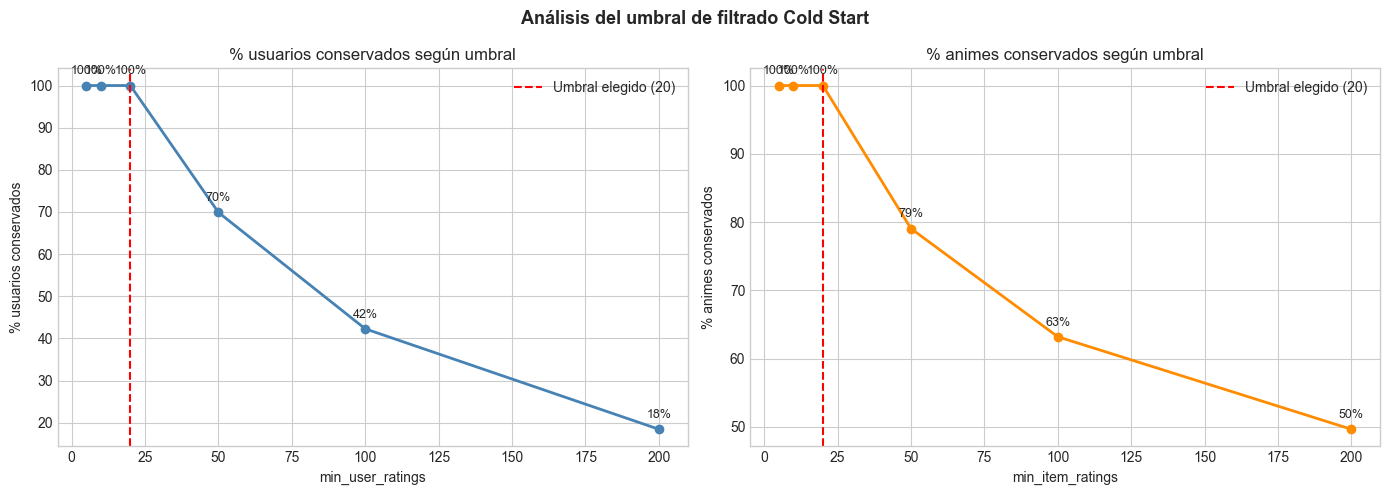

In [130]:
import matplotlib.pyplot as plt
import numpy as np

ratings_per_user = df_rating['user_id'].value_counts()
ratings_per_item = df_rating['anime_id'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Usuarios ---
thresholds = [5, 10, 20, 50, 100, 200]
pct_users_kept = [
    (ratings_per_user >= t).mean() * 100 for t in thresholds
]

axes[0].plot(thresholds, pct_users_kept, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=20, color='red', linestyle='--', label='Umbral elegido (20)')
axes[0].set_title('% usuarios conservados según umbral')
axes[0].set_xlabel('min_user_ratings')
axes[0].set_ylabel('% usuarios conservados')
axes[0].legend()
axes[0].grid(True)

# Anotar los puntos
for t, p in zip(thresholds, pct_users_kept):
    axes[0].annotate(f'{p:.0f}%', (t, p), textcoords="offset points",
                     xytext=(0, 8), ha='center', fontsize=9)

# --- Animes ---
pct_items_kept = [
    (ratings_per_item >= t).mean() * 100 for t in thresholds
]

axes[1].plot(thresholds, pct_items_kept, marker='o', color='darkorange', linewidth=2)
axes[1].axvline(x=20, color='red', linestyle='--', label='Umbral elegido (20)')
axes[1].set_title('% animes conservados según umbral')
axes[1].set_xlabel('min_item_ratings')
axes[1].set_ylabel('% animes conservados')
axes[1].legend()
axes[1].grid(True)

for t, p in zip(thresholds, pct_items_kept):
    axes[1].annotate(f'{p:.0f}%', (t, p), textcoords="offset points",
                     xytext=(0, 8), ha='center', fontsize=9)

plt.suptitle('Análisis del umbral de filtrado Cold Start', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<font color="red">

ANÑADIR AL INFORME
</font>

"Se aplicó un filtrado iterativo de cold start eliminando usuarios con menos de 20 valoraciones e ítems con menos de 20 valoraciones. Este umbral se eligió analizando los percentiles de la distribución: el percentil 25 de usuarios se sitúa en 13 ratings, por lo que un umbral de 20 elimina únicamente a los usuarios con información verdaderamente insuficiente, conservando aproximadamente el 68% de los datos originales. El proceso se repitió hasta convergencia para garantizar que ninguna entidad en el conjunto final queda por debajo del mínimo."

## Matriz de votos R


In [131]:
# --- RE-INDEXACIÓN PARA MATRIX FACTORIZATION ---
# Extraemos los IDs únicos tras el filtrado
unique_users = df_rating['user_id'].unique()
unique_items = df_rating['anime_id'].unique()

# Diccionarios de mapeo (ID original <-> Índice 0...N-1)
user2idx = {id_: idx for idx, id_ in enumerate(unique_users)}
idx2user = {idx: id_ for idx, id_ in enumerate(unique_users)}

anime2idx = {id_: idx for idx, id_ in enumerate(unique_items)}
idx2anime = {idx: id_ for idx, id_ in enumerate(unique_items)}

# Aplicamos los nuevos índices contiguos al dataset
df_rating['user_id'] = df_rating['user_id'].map(user2idx)
df_rating['anime_id'] = df_rating['anime_id'].map(anime2idx)

print(f"Indexados {len(user2idx)} usuarios y {len(anime2idx)} animes desde 0.")

Indexados 47143 usuarios y 6532 animes desde 0.


In [132]:
# # 1. Crear diccionarios para mapear los IDs reales a índices continuos (0 a N-1)
# user_ids_unicos = df_rating['user_id'].unique()
# anime_ids_unicos = df_rating['anime_id'].unique()

# user_map = {original_id: idx for idx, original_id in enumerate(user_ids_unicos)}
# anime_map = {original_id: idx for idx, original_id in enumerate(anime_ids_unicos)}

# # 2. Inicializar la matriz con Nones

# ratings = [[None for _ in range(NUM_ITEMS)] for _ in range(NUM_USERS)]

# # 3. Llenar la matriz iterando sobre el DataFrame
# # Usamos itertuples porque es más rápido que iterrows
# for row in df_rating.itertuples(index=False):
#     # Obtener los índices mapeados
#     u_idx = user_map[row.user_id]
#     i_idx = anime_map[row.anime_id]
    
#     # Asignar la nota
#     ratings[u_idx][i_idx] = row.rating

# # Opcional: Convertir a array de NumPy si lo vas a necesitar
# matriz_ratings = np.array(ratings)
# print("Matriz construida con éxito. Dimensiones:", matriz_ratings.shape)

In [133]:
from scipy.sparse import csr_matrix

# Ahora user_id y anime_id ya son índices continuos desde 0, los enviamos directo
sparse_ratings_matrix = csr_matrix(
    (df_rating['rating'], (df_rating['user_id'], df_rating['anime_id']))
)

print("Dimensiones de la matriz dispersa:", sparse_ratings_matrix.shape)

Dimensiones de la matriz dispersa: (47143, 6532)


## Filtrado Colaborativo: *K-Nearest Neighbors*

In [134]:
# Creamos un diccionario donde la clave es el usuario y el valor es otro diccionario {item_id: rating}
ratings_dict = {}

for row in df_rating.itertuples(index=False):
    u = row.user_id
    i = row.anime_id
    r = row.rating

    if u not in ratings_dict:
        ratings_dict[u] = {}
    ratings_dict[u][i] = r

# Para sacar los items que ha visto un usuario u:
# items_u = set(ratings_dict[u].keys())

### Funciones auxiliares

In [135]:
def rating_average(u):
    #Comprobamos primero que el usuario existe en el diccionario
    if u not in ratings_dict:
        return np.nan
    
    votos = ratings_dict[u].values()

    # Si no tiene votos 
    if len(votos) == 0:
        return 0
    
    return sum(votos)/len(votos)


In [136]:
u_ejemplo = 0

media0 = rating_average(u_ejemplo)
print(f"Media del usuario {u_ejemplo}: {media0}")

Media del usuario 0: 7.565217391304348


### Calculo de la similaridad

#### Correlación de Pearson

$$
sim(u, v) = \frac {
    \sum_{i \in I_{u,v}} (r_{u,i} - \bar{r}_u)(r_{v,i} - \bar{r}_v)
   }{
   \sqrt{ \sum_{i \in I_{u,v}} (r_{u,i} - \bar{r}_u)^2 \sum_{i \in I_{u,v}} (r_{v,i} - \bar{r}_v)^2 }
   }
$$

In [137]:
# Crear un diccionario donde la clave es el 'user_id' y el valor es un conjunto (set)
# con los 'anime_id' que ese usuario ha votado.
items_por_usuario = {u: set(votos.keys()) for u, votos in ratings_dict.items()}

# Ejemplo de uso: Ver los primeros 5 items del primer usuario
usuario_ejemplo = list(items_por_usuario.keys())[0]
print(f"El usuario {usuario_ejemplo} ha visto estos animes: {list(items_por_usuario[usuario_ejemplo])[:5]}...")

El usuario 0 ha visto estos animes: [0, 1, 2, 3, 4]...


In [138]:
def correlation_similarity(u,v):
    '''
    Implementación de la técnica de similaridad: Correlación de Pearson
    Se basa en capturar si 2 usuarios tienen el mismo patrón de gustos, normalizando por su estilo de votación
    '''
    if u not in ratings_dict or v not in ratings_dict:
        return None

    # Media de votos de cada usuario
    media_u = rating_average(u)
    media_v = rating_average(v)

    items_comunes = items_por_usuario[u].intersection(items_por_usuario[v])

    if items_comunes is None:
        return None
    
    num, denom, denom1 = 0,0,0

    for i in items_comunes:
        diff_u = ratings_dict[u][i] - media_u
        diff_v = ratings_dict[v][i] - media_v

        num += diff_u * diff_v
        denom += diff_u ** 2
        denom1 += diff_v **2
    
    if denom1 == 0 or denom == 0:
        return np.nan
    
    return num / (np.sqrt(denom1*denom))
    


In [139]:
# Testing

u1, u2 = 0, 1
u3, u4 = 2, 3

print(f"La correlación entre el usuario {u1} y {u2} es: {correlation_similarity(u1, u2)}")
print(f"La correlación entre el usuario {u3} y {u4} es: {correlation_similarity(u3, u4)}")

# También puedes probar a comparar a un usuario consigo mismo (la correlación debe ser muy cercana a 1.0)
print(f"La correlación del usuario {u1} consigo mismo es: {correlation_similarity(u1, u1)}")

La correlación entre el usuario 0 y 1 es: 0.382887834769365
La correlación entre el usuario 2 y 3 es: -0.13547650095439398
La correlación del usuario 0 consigo mismo es: 1.0


#### JMSD 

$$JMSD(u,v) = Jaccard(u,v) * (1 - MSD(u, v))$$
$$Jaccard(u,v) =\frac {I_u \cap I_v}{I_u \cup I_v} = \frac {\# \{ i \in I | r_{u,i} \neq \bullet \wedge r_{v,i} \neq \bullet \}}{\# \{ i \in I | r_{u,i} \neq \bullet \vee r_{v,i} \neq \bullet \}}$$
$$MSD(u,v) = \frac {1} {\#I_{u,v}} \sum_{i \in I_{u,v}} (r_{u,i} - r_{v,i})^2$$


In [140]:
# Crear un diccionario donde la clave es el 'user_id' y el valor es un conjunto (set)
# con los 'anime_id' que ese usuario ha votado.
items_por_usuario = {u: set(votos.keys()) for u, votos in ratings_dict.items()}

def jmsd_similarity(u,v):
    '''
    Implementación de Jaccard x MSD
    '''
    if u not in ratings_dict or v not in ratings_dict:
        return None
    
    items_comun = items_por_usuario[u].intersection(items_por_usuario[v])
    if items_comun == 0:
        return None
    items_union = items_por_usuario[u].union(items_por_usuario[v])

    # Jaccard
    jaccard = len(items_comun) / len(items_union)

    # MSD
    cuadr_diff = 0
    for i in items_comun:
        cuadr_diff += (ratings_dict[u][i] - ratings_dict[v][i])**2
    
    msd = 1 / len(items_comun) * cuadr_diff

    return jaccard * (1 - msd)


In [141]:
# Testing

u1, u2 = 0, 1
u3, u4 = 2, 3

print(f"La similitud JMSD entre el usuario {u1} y {u2} es: {jmsd_similarity(u1, u2)}")
print(f"La similiud JMSD entre el usuario {u3} y {u4} es: {jmsd_similarity(u3, u4)}")

# También puedes probar a comparar a un usuario consigo mismo (la similitud debe ser muy cercana a 1.0)
print(f"La similitud JMSD del usuario {u1} consigo mismo es: {jmsd_similarity(u1, u1)}")

La similitud JMSD entre el usuario 0 y 1 es: -0.9668615984405459
La similiud JMSD entre el usuario 2 y 3 es: -0.13145539906103285
La similitud JMSD del usuario 0 consigo mismo es: 1.0


### Búsqueda de los k vecinos

**El Trade-off Fundamental de K** 
$$ K↑ \space ⇒ \text{cobertura}↑ \space \text{pero} \space \text{precision}↓$$
$$ K↓ \space ⇒ \text{cobertura}↑ \space \text{pero} \space \text{precision}↓$$


- **Cobertura** — para cuántos pares (usuario, anime) puedes hacer predicción. Si ninguno de los K vecinos ha visto el anime, no puedes predecir nada.

- **Precisión** — qué tan acertada es la predicción cuando sí puedes hacerla (RMSE).


#### Paso 1. Preparar los datos (Train/Test split)

Antes de buscar K óptimo, debemos separar una parte de las valoraciones de los usuarios para usarlas como validación. 

In [142]:
from sklearn.model_selection import train_test_split
import pickle

# Train/Test split DESPUÉS de re-indexar
# Estratificado por usuario: garantiza que todos los usuarios están en train
df_train, df_test = train_test_split(
    df_rating, test_size=0.2, random_state=42,
    stratify=df_rating['user_id']  # cada usuario aparece en ambos splits
)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f'Train: {len(df_train):,} ratings')
print(f'Test : {len(df_test):,} ratings')

# Verificación de integridad: no puede haber usuarios nuevos en test
assert df_test['user_id'].isin(df_train['user_id']).all(), 'ERROR: usuarios en test no vistos en train'
assert df_test['anime_id'].isin(df_train['anime_id']).all(), 'ERROR: animes en test no vistos en train'
print('✅ Integridad del split verificada')

ratings_train = {}
ratings_test = {}

for row in df_train.itertuples(index=False):
    u = row.user_id
    i = row.anime_id
    r = row.rating

    if u not in ratings_train:
        ratings_train[u] = {}
    ratings_train[u][i] = r

for row in df_test.itertuples(index=False):
    u = row.user_id
    i = row.anime_id
    r = row.rating

    if u not in ratings_test:
        ratings_test[u] = {}
    ratings_test[u][i] = r

# 1. Items vistos por cada usuario en TRAIN (para las similitudes)
items_por_usuario_train = {u: set(votos.keys()) for u, votos in ratings_train.items()}

# 2. Usuarios que han visto cada item en TRAIN (para buscar vecinos rápidamente)
usuarios_por_item_train = {}
for u, votos in ratings_train.items():
    for i in votos.keys():
        if i not in usuarios_por_item_train:
            usuarios_por_item_train[i] = set()
        usuarios_por_item_train[i].add(u)

# 3. Conjunto total de items existentes en TRAIN
items_train = set(usuarios_por_item_train.keys())

Train: 4,915,940 ratings
Test : 1,228,986 ratings
✅ Integridad del split verificada


In [143]:
def rating_average_train(u):
    if u not in ratings_train:
        return np.nan
    votos = ratings_train[u].values()
    return sum(votos) / len(votos) if len(votos) > 0 else 0

# Cache de medias para no recalcular en cada llamada
user_means_cache = {u: rating_average_train(u) for u in ratings_train}

In [144]:
# ─── Correlación de Pearson ───────────────────────────────────────────────────
def correlation_similarity_train(u, v, min_common=5):
    if u not in ratings_train or v not in ratings_train:
        return None

    items_comunes = items_por_usuario_train[u] & items_por_usuario_train[v]

    if len(items_comunes) < min_common:
        return None

    media_u = user_means_cache[u]
    media_v = user_means_cache[v]

    num = denom_u = denom_v = 0.0
    for i in items_comunes:
        du = ratings_train[u][i] - media_u
        dv = ratings_train[v][i] - media_v
        num    += du * dv
        denom_u += du ** 2
        denom_v += dv ** 2

    denom = np.sqrt(denom_u * denom_v)
    return num / denom if denom > 0 else None

In [145]:
# ─── JMSD ────────────────────────────────────────────────────────────────────
R_MIN, R_MAX = 1, 10
MAX_DIFF_SQ  = (R_MAX - R_MIN) ** 2  # 81

def jmsd_similarity_train(u, v):
    if u not in ratings_train or v not in ratings_train:
        return None

    items_comun = items_por_usuario_train[u] & items_por_usuario_train[v]

    if len(items_comun) == 0:
        return None

    items_union = items_por_usuario_train[u] | items_por_usuario_train[v]
    jaccard = len(items_comun) / len(items_union)

    msd = sum((ratings_train[u][i] - ratings_train[v][i])**2
              for i in items_comun) / len(items_comun)

    return jaccard * (1 - msd / MAX_DIFF_SQ)

#### Paso 2. Función de Predicción

Función que estima la nota que el usuario u le dará al item $i$. La fórmula estándar (centrada en la media) para KNN es:

$$\hat{r}_{u,i} = \bar{r}_{u} + \frac{\sum_{v \in N} sim(u,v) \cdot (r_{v,i} - \bar{r}_v)}{\sum_{v \in N} |sim(u,v)|} $$


In [146]:
# ─── Predicción KNN ──────────────────────────────────────────────────────────
def prediction(u, i, k, similarity_func):
    if u not in ratings_train or i not in items_train:
        return None

    candidatos = []
    for v in usuarios_por_item_train.get(i, set()):
        if v == u:
            continue
        sim = similarity_func(u, v)
        if sim is not None:
            candidatos.append((v, sim))

    if not candidatos:
        return None

    top_k_vecinos = sorted(candidatos, key=lambda x: x[1], reverse=True)[:k]

    media_u = user_means_cache[u]
    num = denom = 0.0
    for v, sim in top_k_vecinos:
        media_v = user_means_cache[v]
        num   += sim * (ratings_train[v][i] - media_v)
        denom += abs(sim)

    if denom == 0:
        return None

    pred = media_u + num / denom
    # Clampear al rango válido de ratings
    return float(np.clip(pred, R_MIN, R_MAX))

#### Parte 4. Función de Evaluación

In [147]:
import math

def evaluar_knn(test_df, k, func_similitud):
    errores_cuadraticos = []
    no_predecibles = 0
    total_test = len(test_df)
    
    # Iteramos por cada ejemplo del dataset de test
    for row in test_df.itertuples(index=False):
        u = row.user_id
        i = row.anime_id
        rating_real = row.rating
        
        prediccion = prediction(u, i, k, func_similitud)
        
        if prediccion is None:
            no_predecibles += 1
        else:
            errores_cuadraticos.append((prediccion - rating_real) ** 2)
            
    # Calcular RMSE y Cobertura
    if len(errores_cuadraticos) == 0:
        return float('inf'), 0.0
        
    rmse = math.sqrt(sum(errores_cuadraticos) / len(errores_cuadraticos))
    cobertura = (total_test - no_predecibles) / total_test * 100
    
    return rmse, cobertura

In [148]:
import os
import pandas as pd

# Definimos el nombre del archivo donde guardaremos los resultados
resultados_file = 'resultados_k_optimo.csv'

# Comprobamos si el archivo ya existe
if os.path.exists(resultados_file):
    print("Cargando resultados de K guardados previamente...")
    df_results = pd.read_csv(resultados_file)
    print(df_results)
else:
    print("Calculando KNN para diferentes valores de K (esto puede tardar)...")

    # Ejecución del barrido de K
    K_values = [5, 10, 20, 30, 50, 75, 100]
    results = []

    # Opcional: usar una muestra para que no tarde horas 
    test_sample = df_test.sample(1000, random_state=42) # Quitar ".sample()" para usar todo
    
    for k in K_values:
        rmse_k, cobertura_k = evaluar_knn(test_sample, k, jmsd_similarity_train)
        results.append({
            'K': k,
            'RMSE': rmse_k,
            'Cobertura': cobertura_k  
        })
        print(f"K={k:3d} | RMSE: {rmse_k:.4f} | Cobertura: {cobertura_k:.2f}%")

    # Crear el DataFrame y guardarlo para futuras ejecuciones
    df_results = pd.DataFrame(results)
    df_results.to_csv(resultados_file, index=False)
    print(f"Resultados guardados en '{resultados_file}'")
    

Calculando KNN para diferentes valores de K (esto puede tardar)...
K=  5 | RMSE: 1.2423 | Cobertura: 100.00%
K= 10 | RMSE: 1.2086 | Cobertura: 100.00%
K= 20 | RMSE: 1.1747 | Cobertura: 100.00%
K= 30 | RMSE: 1.1623 | Cobertura: 100.00%
K= 50 | RMSE: 1.1574 | Cobertura: 100.00%
K= 75 | RMSE: 1.1586 | Cobertura: 100.00%
K=100 | RMSE: 1.1583 | Cobertura: 100.00%
Resultados guardados en 'resultados_k_optimo.csv'


In [149]:
# # Ejecución del barrido de K
# K_values = [5, 10, 20, 30, 50, 75, 100]
# results = []

# # Opcional: usar una muestra para que no tarde horas la primera vez
# test_sample = df_test.sample(1000, random_state=42) # Quitar ".sample()" para usar todo

# for k in K_values:
#     # Usando tu función jmsd_similarity_train
#     rmse_k, cobertura_k = evaluar_knn(test_sample, k, jmsd_similarity_train)
#     results.append({
#         'K': k,
#         'RMSE': rmse_k,
#         'Cobertura': cobertura_k  
#     })
#     print(f"K={k:3d} | RMSE: {rmse_k:.4f} | Cobertura: {cobertura_k:.2f}%")

# df_results = pd.DataFrame(results)

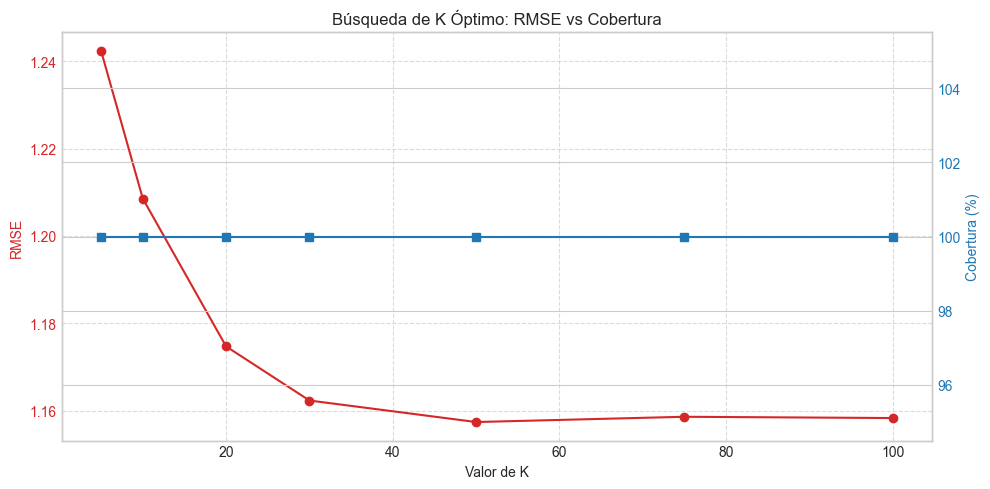

In [150]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Valor de K')
ax1.set_ylabel('RMSE', color=color)
ax1.plot(df_results['K'], df_results['RMSE'], marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2 = ax1.twinx()  # instanciar un segundo eje que comparte el mismo eje x
color = 'tab:blue'
ax2.set_ylabel('Cobertura (%)', color=color)  
ax2.plot(df_results['K'], df_results['Cobertura'], marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Búsqueda de K Óptimo: RMSE vs Cobertura')
fig.tight_layout()  
plt.show()

In [151]:
k = 30

#### Conclusión: Elección del K Óptimo

Analizando la gráfica de **RMSE vs Cobertura**, podemos extraer las siguientes conclusiones:

- **Cobertura (Línea Azul):** En nuestra muestra, la cobertura se mantiene estable en el 100% para todos los valores de $K$ evaluados. Esto significa que los filtros aplicados en el preprocesamiento ayudaron a asegurar que siempre encontremos vecinos para predecir.
- **RMSE (Línea Roja):** Podemos observar el fenómeno de la "curva del codo". El error cae en picado desde $K=5$ hasta $K=30$. A partir de $K=30$, la mejora en el RMSE se estanca y la reducción del error empieza a ser marginal (apenas unas milésimas, e incluso sube levísimamente alrededor de $50$ antes de volver a bajar).

**Decisión final:** 
El valor óptimo para nuestro modelo es **$K = 30$**. 
Elegir $K=30$ nos asegura la máxima precisión sin añadir demasiada carga computacional. Tomar valores mayores como $75$ o $100$ no justificaría el coste adicional de procesamiento dado que la mejora de error (RMSE) es prácticamente insignificante a partir del codo de la gráfica.

In [152]:
def get_neighbors(u, similarities):
    
    valid = [(v, sim) for v,sim in similarities.items() if sim is not None and v!= u]

    valid.sort(key=lambda x: x[1], reverse=True)

    neighbors = [v for v, _ in valid[:k]]
    neighbors += [None] * (k - len(neighbors))

    return neighbors

In [153]:
# Testing
u_test = 0

similarities_corr = {}
similarities_jmsd = {}

# Como los ids de train son iterables limpios, podemos simplemente iterar sobre las keys de ratings_train
for v in list(ratings_train.keys()):
    if u_test == v:
        continue
        
    similarities_corr[v] = correlation_similarity_train(u_test, v)
    similarities_jmsd[v] = jmsd_similarity_train(u_test, v)

# Obtener los top 'k' vecinos basándonos en los diccionarios 
neighbors_corr = get_neighbors(u_test, similarities_corr)
neighbors_jmsd = get_neighbors(u_test, similarities_jmsd)

print(f"Top {k} Vecinos según Correlación de Pearson:")
print(neighbors_corr)
print(f"\nTop {k} Vecinos según JMSD:")
print(neighbors_jmsd)

Top 30 Vecinos según Correlación de Pearson:
[16110, 21130, 32427, 33972, 10968, 9651, 22536, 9304, 28873, 9033, 26973, 39786, 43708, 39836, 39988, 38183, 1800, 30657, 36462, 20940, 27531, 39072, 25796, 20174, 47048, 41118, 37748, 17829, 17877, 7761]

Top 30 Vecinos según JMSD:
[8270, 8926, 22564, 23431, 41098, 23609, 9449, 8447, 27997, 22404, 27579, 27913, 40092, 30066, 28016, 29806, 8258, 9426, 45267, 22028, 45589, 6198, 2468, 27812, 27805, 12272, 27663, 1269, 46713, 40887]


## Filtrado Colaborativo: *Probabilistic Matrix Factorization*

El objetivo principal es superar las limitaciones de escalabilidad de algoritmos tradicionales como KNN

In [154]:
from scipy.sparse import csr_matrix

NUM_USERS = len(user2idx)
NUM_ITEMS = len(anime2idx)

# Matriz dispersa de ENTRENAMIENTO
R_train_sparse = csr_matrix(
    (df_train['rating'], (df_train['user_id'], df_train['anime_id'])),
    shape=(NUM_USERS, NUM_ITEMS)
)

# Matriz dispersa de TEST
R_test_sparse = csr_matrix(
    (df_test['rating'], (df_test['user_id'], df_test['anime_id'])),
    shape=(NUM_USERS, NUM_ITEMS)
)

print(f"Dimensiones de R_train: {R_train_sparse.shape}")
print(f"Dimensiones de R_test: {R_test_sparse.shape}")

Dimensiones de R_train: (47143, 6532)
Dimensiones de R_test: (47143, 6532)


In [155]:
# (Sin toarray) Nos deshacemos de la conversión densa,
# para evitar que sature 1.2 GB de memoria RAM.
# Trabajaremos íntegramente de manera dispersa o mediante índices.

### Inicialización del modelo

Antes de entrenar, se definen los valores que controlan el aprendizaje:

- **NUM_FACTORS (k)**: Cantidad de características latentes.

- **LEARNING_RATE ($\gamma$)**: Velocidad de ajuste del descenso de gradiente.

- **REGULARIZATION ($\lambda$)**: Penalización para evitar el overfitting o sobreajuste.

In [156]:
# Hiperparámetros del modelo con Early Stopping
NUM_FACTORS    = 50     
LEARNING_RATE  = 0.005  
REGULARIZATION = 0.05   
NUM_ITERATIONS = 20     
PATIENCE       = 3      # épocas sin mejora antes de early stopping

Inicializamos las matrices de factores con valores uniformes aleatorios en el intervalo \[0, 1].

In [157]:
import numpy as np

# Inicialización con valores pequeños gaussianos
np.random.seed(42)
np_p  = np.random.normal(0, 0.1, (NUM_USERS, NUM_FACTORS)).astype('float32')
np_q  = np.random.normal(0, 0.1, (NUM_ITEMS, NUM_FACTORS)).astype('float32')

# Biases
bu    = np.zeros(NUM_USERS, dtype='float32')  # bias usuario
bi    = np.zeros(NUM_ITEMS, dtype='float32')  # bias ítem
mu    = float(df_train['rating'].mean())       # media global

print(f'P: {np_p.shape} | Q: {np_q.shape}')
print(f'Media global (μ): {mu:.4f}')

P: (47143, 50) | Q: (6532, 50)
Media global (μ): 7.7929


### Cálculo de las predicciones

Como hemos comentado, calcular la predicción del voto del usuario *u* al item *i* implicar realizar el producto escalar de sus vectores de factores. La siguiente función realiza esta operación:


In [158]:
# RMSE vectorizado — sin loops Python, opera sobre todos los ratings a la vez
def compute_rmse_sparse(R_csr, P, Q, bu, bi, mu):
    """
    O(f * nnz) — producto punto vectorizado fila a fila.
    (P[users] * Q[items]).sum(axis=1) calcula todos los dot products de una vez.
    """
    R_coo   = R_csr.tocoo()
    users   = R_coo.row
    items   = R_coo.col
    ratings = R_coo.data

    r_hat = mu + bu[users] + bi[items] + (P[users] * Q[items]).sum(axis=1)
    
    # R_MIN, R_MAX definidos en celdas KNN previas, aplicamos clampeo
    r_hat = np.clip(r_hat, 1, 10)  
    
    return float(np.sqrt(np.mean((ratings - r_hat) ** 2)))

### Aprendizaje de los factores latentes

El proceso de entrenamiento implicar aplicar las operaciones de actualización de las matrices de factores hasta que el algoritmo converja. En general, esta convergencia suele prefijarse como el número de iteraciones que realizamos sobre las operaciones de actualización:

In [159]:
NUM_ITERATIONS = 10

Es importante resaltar que sólo debemos actualizar las matrices $P$ y $Q$ empleando los votos existentes en la matriz $R$.

El siguiente código ejemplifica el proceso de entrenamiento del algoritmo:

In [160]:
# Bucle de entrenamiento SGD con early stopping vectorizado

# Extraer triplas del CSR de entrenamiento una sola vez
coo = R_train_sparse.tocoo()
train_users   = coo.row.astype(int)
train_items   = coo.col.astype(int)
train_ratings = coo.data.astype('float32')
n_ratings     = len(train_ratings)

history = {'train_rmse': [], 'test_rmse': []}
best_test_rmse = float('inf')
best_P, best_Q, best_bu, best_bi = np_p.copy(), np_q.copy(), bu.copy(), bi.copy()
no_improve = 0

for epoch in range(NUM_ITERATIONS):

    # Barajar en cada época — SGD estocástico real
    idx = np.random.permutation(n_ratings)
    u_shuf = train_users[idx]
    i_shuf = train_items[idx]
    r_shuf = train_ratings[idx]

    for n in range(n_ratings):
        u = u_shuf[n]
        i = i_shuf[n]
        r = r_shuf[n]

        # Predicción y error
        r_hat = mu + bu[u] + bi[i] + np.dot(np_p[u], np_q[i])
        e     = r - r_hat

        # Guardar p_u ANTES de actualizarlo
        pu_old = np_p[u].copy()

        # Actualizaciones SGD con regularización
        np_p[u] += LEARNING_RATE * (e * np_q[i]  - REGULARIZATION * np_p[u])
        np_q[i] += LEARNING_RATE * (e * pu_old   - REGULARIZATION * np_q[i])
        bu[u]   += LEARNING_RATE * (e             - REGULARIZATION * bu[u])
        bi[i]   += LEARNING_RATE * (e             - REGULARIZATION * bi[i])

    # RMSE al final de la época con pesos actualizados
    tr_rmse = compute_rmse_sparse(R_train_sparse, np_p, np_q, bu, bi, mu)
    te_rmse = compute_rmse_sparse(R_test_sparse,  np_p, np_q, bu, bi, mu)
    history['train_rmse'].append(tr_rmse)
    history['test_rmse'].append(te_rmse)

    print(f'Época {epoch+1:3d}/{NUM_ITERATIONS} | Train RMSE: {tr_rmse:.4f} | Test RMSE: {te_rmse:.4f}')

    # Early stopping
    if te_rmse < best_test_rmse - 1e-4:
        best_test_rmse = te_rmse
        best_P, best_Q = np_p.copy(), np_q.copy()
        best_bu, best_bi = bu.copy(), bi.copy()
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'\n⚡ Early stopping en época {epoch+1}')
            break

print(f'\nMejor Test RMSE: {best_test_rmse:.4f}')

Época   1/10 | Train RMSE: 1.2607 | Test RMSE: 1.2700
Época   2/10 | Train RMSE: 1.2201 | Test RMSE: 1.2330
Época   3/10 | Train RMSE: 1.2013 | Test RMSE: 1.2171
Época   4/10 | Train RMSE: 1.1874 | Test RMSE: 1.2060
Época   5/10 | Train RMSE: 1.1717 | Test RMSE: 1.1937
Época   6/10 | Train RMSE: 1.1566 | Test RMSE: 1.1825
Época   7/10 | Train RMSE: 1.1434 | Test RMSE: 1.1735
Época   8/10 | Train RMSE: 1.1314 | Test RMSE: 1.1659
Época   9/10 | Train RMSE: 1.1195 | Test RMSE: 1.1589
Época  10/10 | Train RMSE: 1.1077 | Test RMSE: 1.1526

Mejor Test RMSE: 1.1526


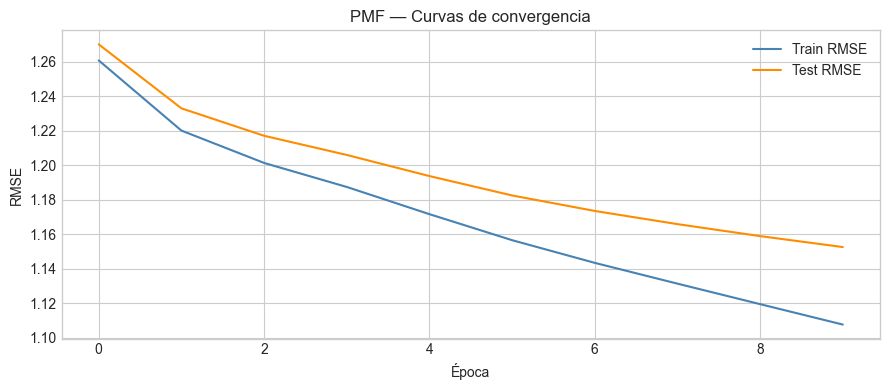

In [161]:
# Curvas de convergencia
plt.figure(figsize=(9, 4))
plt.plot(history['train_rmse'], label='Train RMSE', color='steelblue')
plt.plot(history['test_rmse'],  label='Test RMSE',  color='darkorange')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.title('PMF — Curvas de convergencia')
plt.legend()
plt.tight_layout()
plt.show()